# XGBoost

Post-binning contig correctness prediction on the bundled SPAdes example data.

This notebook discovers dataset folders under `tests/data/` and reads each folder's `initial_contig_bins.csv` as the initial binner output. The target is `0` for an incorrect initial bin assignment and `1` for a correct assignment among binned contigs.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
try:
    import seaborn as sns
except ImportError:
    sns = None

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "tests" / "data").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))

for module_name in [
    "binfailgraph.datasets",
    "binfailgraph.features",
    "binfailgraph.labels",
    "binfailgraph.modeling",
]:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from binfailgraph.datasets import discover_datasets
from binfailgraph.features import build_feature_table
from binfailgraph.labels import make_contig_labels, task_frame
from binfailgraph.modeling import (
    COMPARISON_FEATURE_SETS,
    combined_dataset_metric_table,
    combined_task_frame,
    comparison_feature_columns,
    compare_feature_sets,
    plot_combined_dataset_roc_curves,
    plot_feature_boxplots_by_outcome,
    plot_feature_set_roc_curves,
    plot_transfer_heatmap,
    select_feature_columns,
    transfer_feature_set_table,
)

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")
DATA_ROOT = ROOT / "tests" / "data"
DATASETS = discover_datasets(DATA_ROOT)
INCLUDE_KMERS = True
TASK = "misbin"

## Data and Labels

In [2]:
dataset_features = {}
dataset_labelled = {}
dataset_tasks = {}
dataset_summary_rows = []

for dataset in DATASETS:
    raw_features = build_feature_table(
        graph_file=dataset.graph_file,
        contigs_file=dataset.contigs_file,
        contig_paths_file=dataset.contig_paths_file,
        ground_truth_file=dataset.ground_truth_file,
        bin_assignments_file=dataset.bin_assignments_file,
        include_kmers=INCLUDE_KMERS,
    )
    labelled = make_contig_labels(raw_features)
    task = task_frame(labelled, task=TASK)

    dataset_features[dataset.name] = raw_features
    dataset_labelled[dataset.name] = labelled
    dataset_tasks[dataset.name] = task
    dataset_summary_rows.append(
        {
            "dataset": dataset.name,
            "graph_contigs": len(raw_features),
            "initial_binned_contigs": int(raw_features["bin"].notna().sum()),
            "task_rows": len(task),
            "incorrect_assignments": int((task["target"] == 0).sum()),
            "correct_assignments": int(task["target"].sum()),
        }
    )

print("Target convention: 0 = incorrect initial bin assignment, 1 = correct initial bin assignment")
display(pd.DataFrame(dataset_summary_rows))

Target convention: 0 = incorrect initial bin assignment, 1 = correct initial bin assignment


,dataset,graph_contigs,initial_binned_contigs,task_rows,incorrect_assignments,correct_assignments
0,Sim-10G,920,341,331,25,306
1,Sim-5G,519,209,206,14,192


## Feature Distributions

Boxplots compare correct and failed contigs after pooling all discovered datasets. The plotted features exclude raw 136-dimensional 4-mer vectors but include the collapsed `4mer_composition_distance` feature and the within-bin `coverage_difference` feature. Asterisks use two-sided Mann-Whitney U tests with Benjamini-Hochberg FDR correction.

Plotting 31 comparison features pooled across 2 datasets.


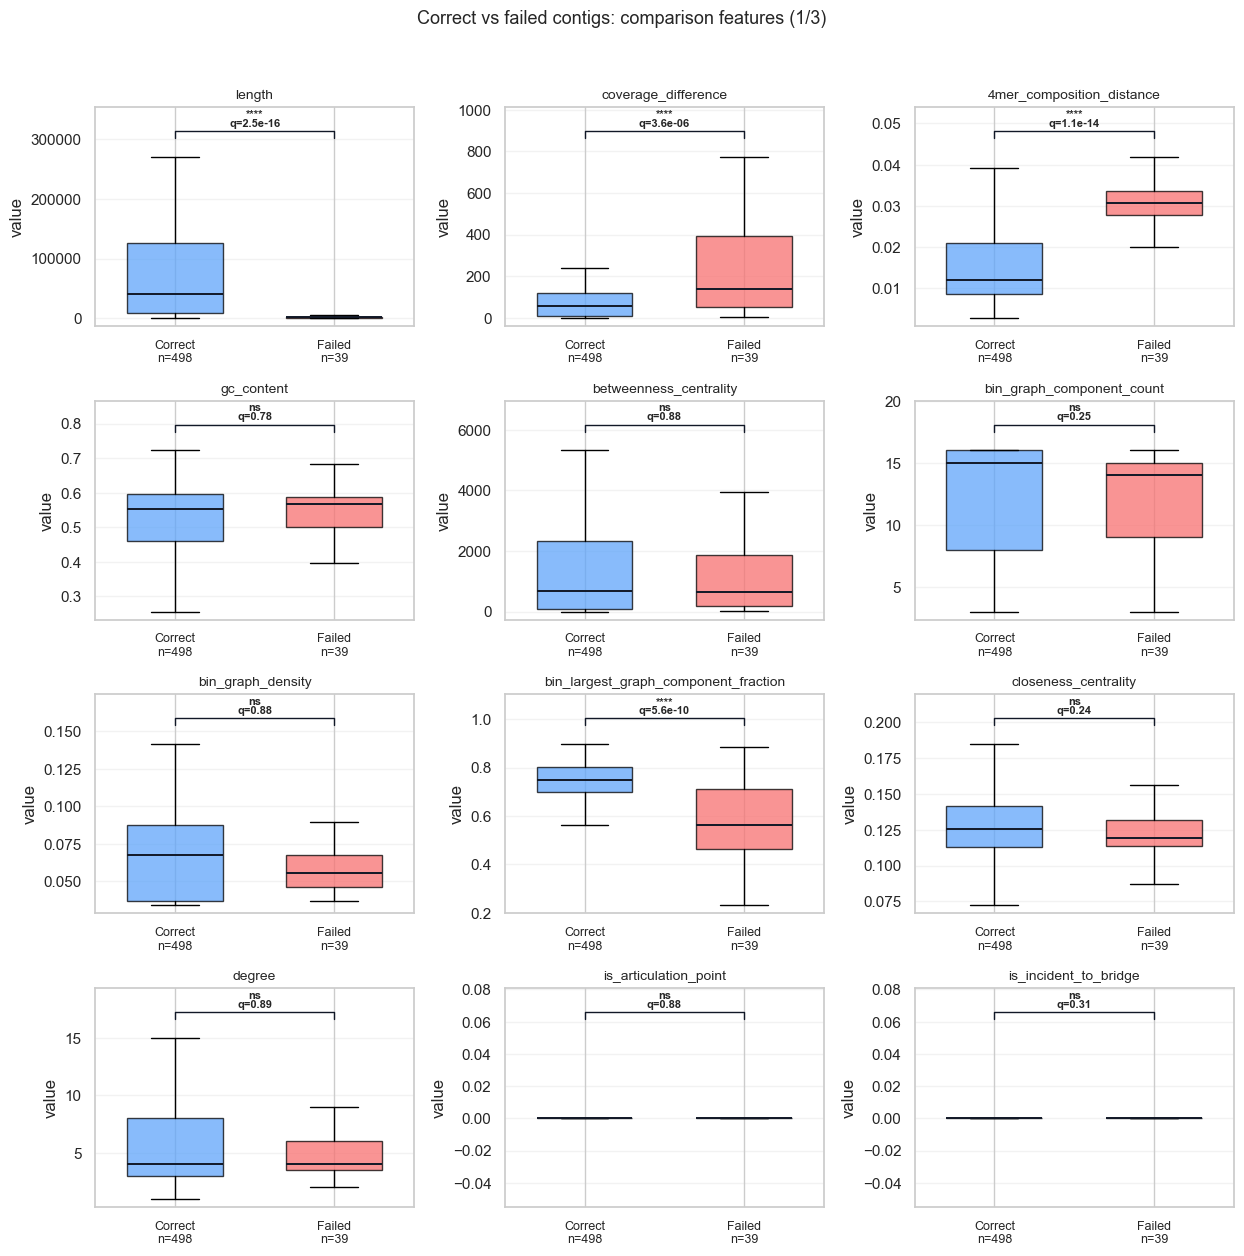

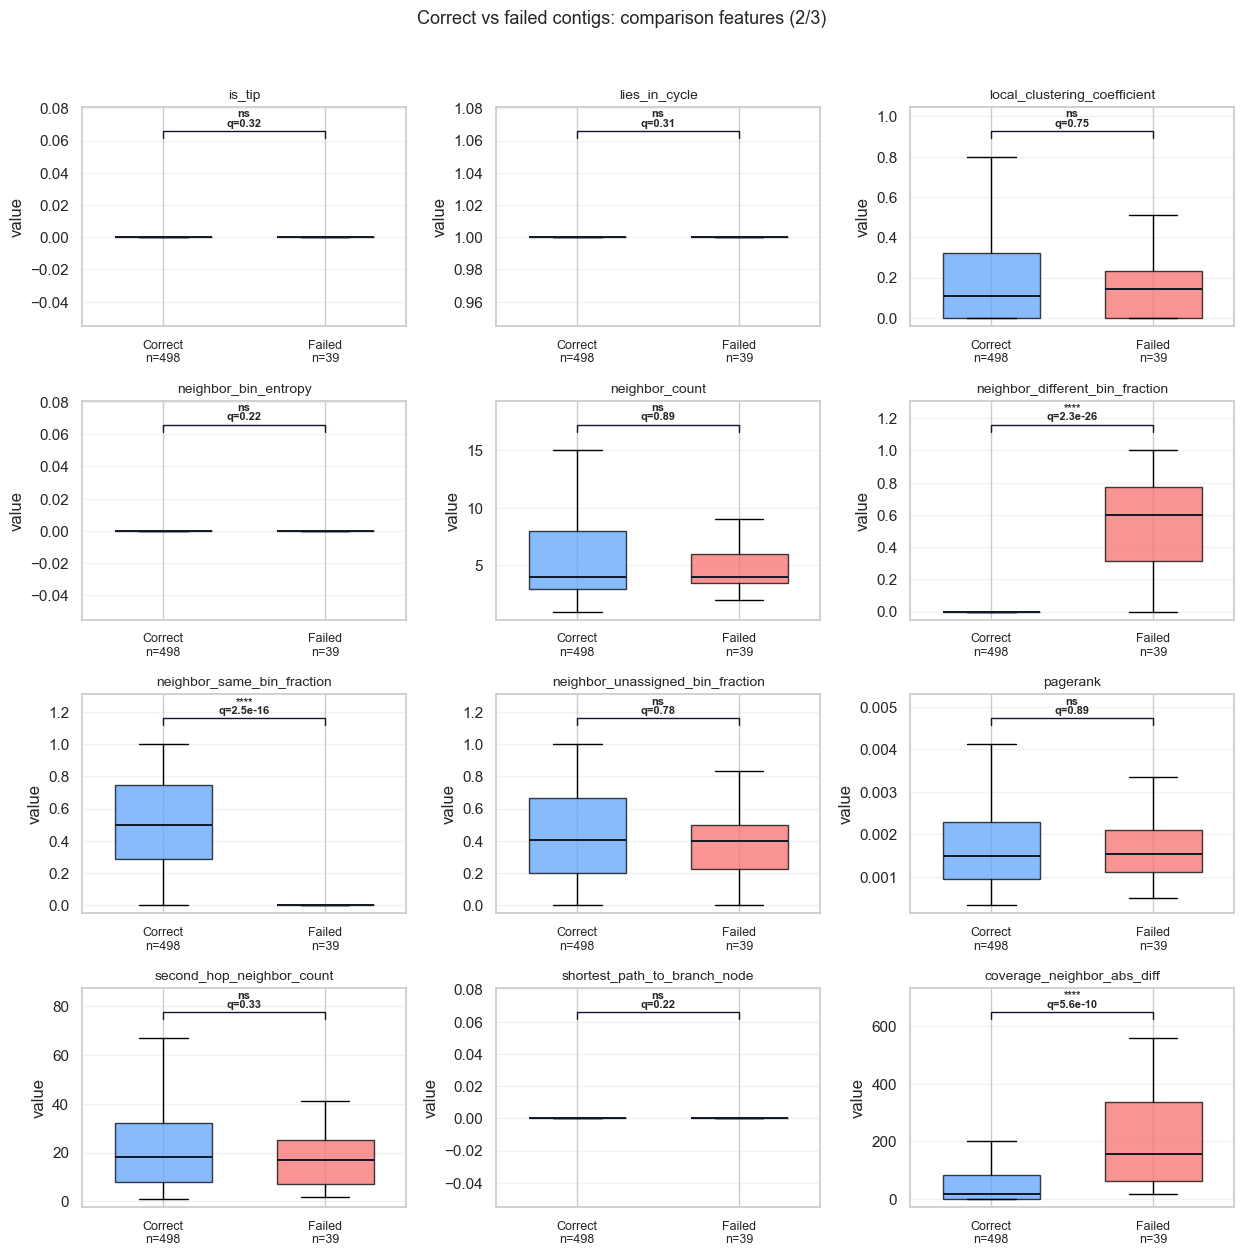

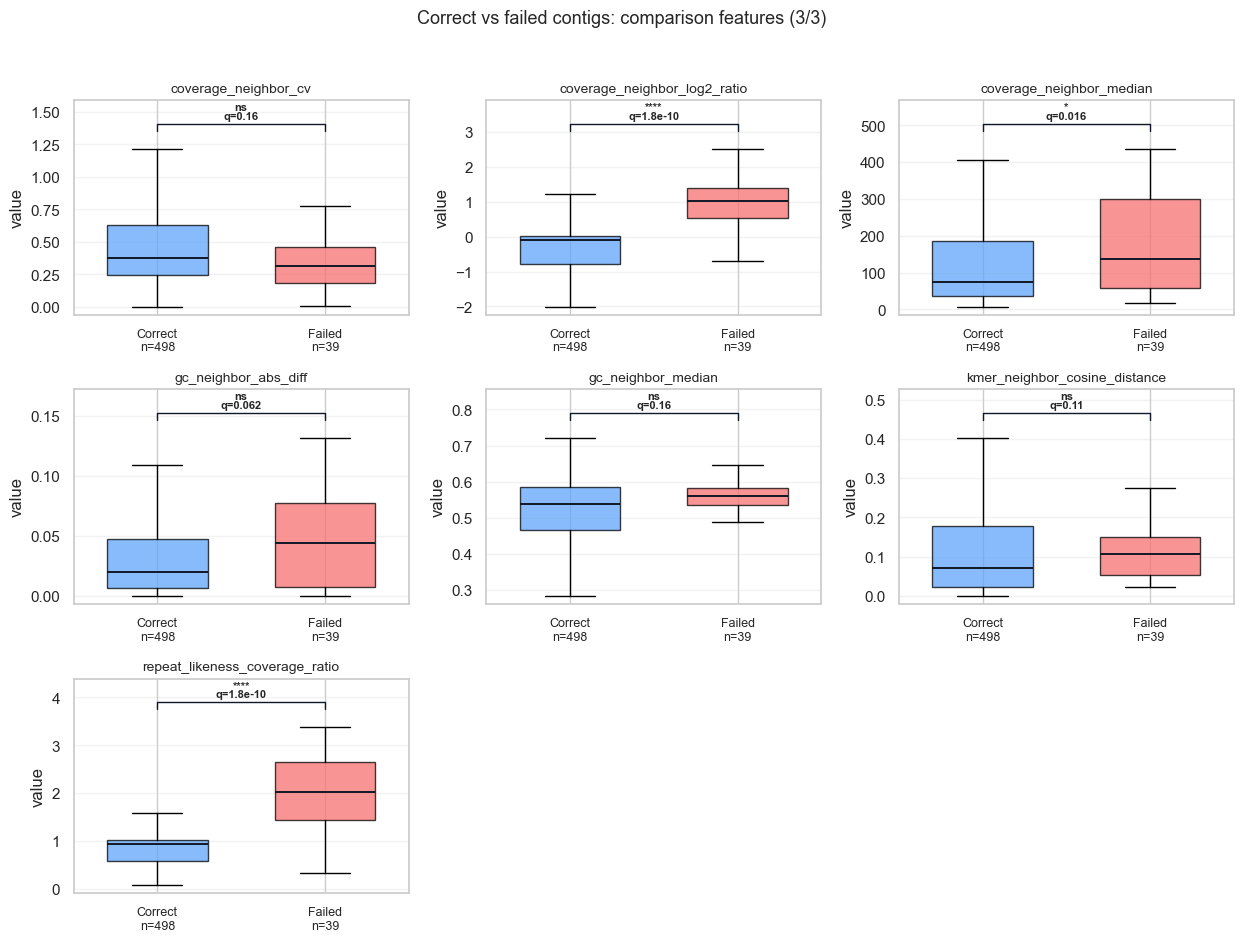

In [3]:
pooled_task = combined_task_frame(dataset_tasks)
distribution_feature_columns = comparison_feature_columns(
    pooled_task,
    feature_sets=COMPARISON_FEATURE_SETS,
)
print(
    f"Plotting {len(distribution_feature_columns)} comparison features pooled across "
    f"{len(dataset_tasks)} datasets."
)
_feature_distribution_figures = plot_feature_boxplots_by_outcome(
    pooled_task,
    distribution_feature_columns,
    features_per_figure=12,
    ncols=3,
    showfliers=False,
    p_adjust="fdr_bh",
)
plt.show()

## Model

In [4]:
from binfailgraph.modeling import make_xgboost

MODEL_NAME = "XGBoost"
def MODEL_FACTORY(current_task):
    return make_xgboost(y_train=current_task["target"], random_state=42)

## Feature-Set Comparison

The same model is evaluated with five feature sets: length only, coverage-difference only, composition + coverage difference, graph only, and composition + coverage difference + graph. Performance is reported with AUROC and AUPRC.

In [5]:
comparison_tables = []
comparison_results_by_dataset = {}

for dataset_name, current_task in dataset_tasks.items():
    table, results = compare_feature_sets(
        current_task,
        model_factory=lambda current_task=current_task: MODEL_FACTORY(current_task),
        feature_sets=COMPARISON_FEATURE_SETS,
        target_col="target",
        test_size=0.30,
        random_state=42,
        top_k_fraction=0.10,
    )
    table.insert(0, "dataset", dataset_name)
    comparison_tables.append(table)
    comparison_results_by_dataset[dataset_name] = results

comparison_table = pd.concat(comparison_tables, ignore_index=True)
display(
    comparison_table[
        ["dataset", "feature_set_label", "n_features", "auroc", "auprc"]
    ].style.format({"auroc": "{:.3f}", "auprc": "{:.3f}"})
)

primary_dataset = sorted(dataset_tasks)[0]
primary_task = dataset_tasks[primary_dataset]
result = comparison_results_by_dataset[primary_dataset]["composition_coverage_graph"]
feature_columns = select_feature_columns(primary_task, feature_set="composition_coverage_graph")
print(
    f"Using {primary_dataset!r} and {len(feature_columns):,} composition + coverage difference + graph features "
    "for diagnostics below."
)
display(result.metrics.to_frame("value"))
display(result.test_predictions.head(25))

,dataset,feature_set_label,n_features,auroc,auprc
0,Sim-10G,Length only,1,0.908,0.991
1,Sim-10G,Coverage difference only,1,0.756,0.961
2,Sim-10G,Composition + coverage difference,3,0.955,0.996
3,Sim-10G,Graph only,19,0.980,0.998
4,Sim-10G,Composition + coverage difference + graph,30,1.000,1.000
5,Sim-5G,Length only,1,0.871,0.989
6,Sim-5G,Coverage difference only,1,0.966,0.997
7,Sim-5G,Composition + coverage difference,3,0.931,0.995
8,Sim-5G,Graph only,19,0.978,0.999
9,Sim-5G,Composition + coverage difference + graph,30,1.000,1.000


Using 'Sim-10G' and 30 composition + coverage difference + graph features for diagnostics below.


,value
n_train,231.000000
n_test,100.000000
correct_rate_test,0.920000
f1,0.989011
precision,1.000000
ece_10bin,0.084396
auroc,1.000000
auprc,1.000000
precision_at_top_10pct,1.000000
recall_at_top_10pct,0.108696


,contig,contig_short,target,correctness_score
208,NODE_209_length_36233_cov_8.417243,NODE_209,1,0.990831
131,NODE_132_length_85807_cov_8.914393,NODE_132,1,0.989702
117,NODE_118_length_101466_cov_311.119849,NODE_118,1,0.989541
68,NODE_69_length_175872_cov_322.405433,NODE_69,1,0.989541
284,NODE_285_length_8394_cov_8.062837,NODE_285,1,0.989498
93,NODE_94_length_135505_cov_8.927368,NODE_94,1,0.988889
234,NODE_235_length_23554_cov_290.328057,NODE_235,1,0.988350
163,NODE_164_length_59191_cov_106.967414,NODE_164,1,0.987697
7,NODE_8_length_755993_cov_65.478972,NODE_8,1,0.987609
21,NODE_22_length_460203_cov_65.766106,NODE_22,1,0.987609


## ROC Curves

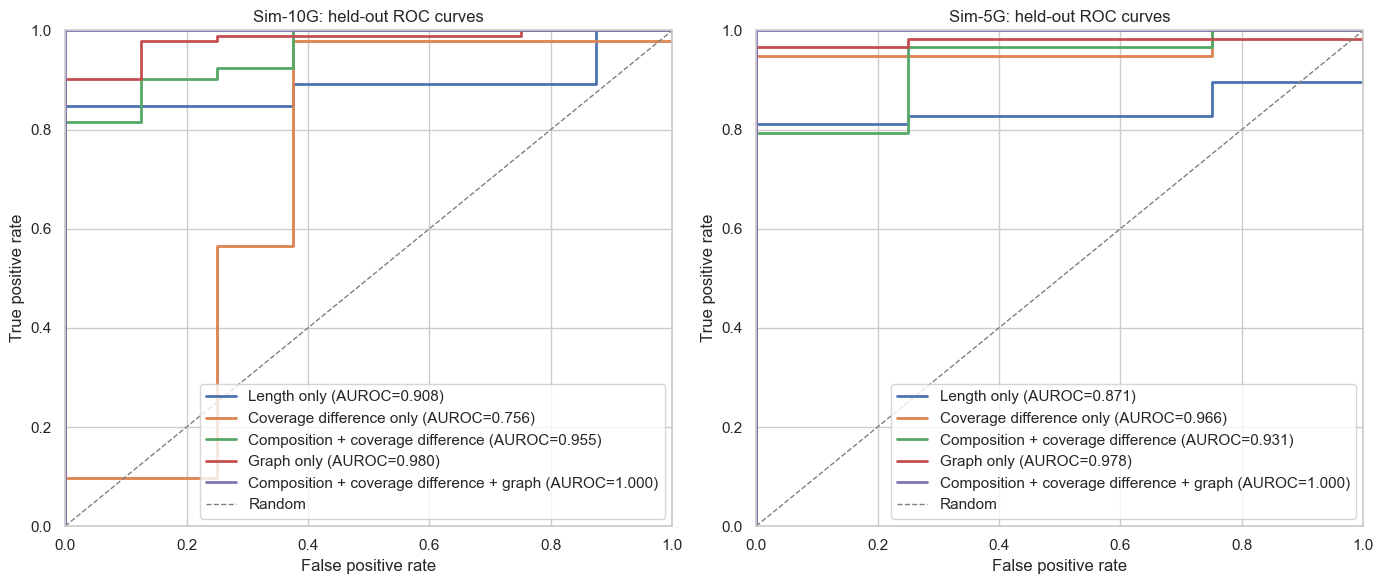

In [6]:
fig, axes = plt.subplots(1, len(comparison_results_by_dataset), figsize=(7 * len(comparison_results_by_dataset), 6))
if len(comparison_results_by_dataset) == 1:
    axes = [axes]

for ax, (dataset_name, results) in zip(axes, comparison_results_by_dataset.items()):
    plot_feature_set_roc_curves(results, ax=ax)
    ax.set_title(f"{dataset_name}: held-out ROC curves")

plt.tight_layout()
plt.show()

## Combined ROC Curves Across Datasets

These curves pool the held-out predictions from each dataset-specific run for the same feature set.

,feature_set_label,n_test,correct_rate,auroc,auprc
0,Length only,162,0.926,0.894,0.991
1,Coverage difference only,162,0.926,0.795,0.967
2,Composition + coverage difference,162,0.926,0.943,0.995
3,Graph only,162,0.926,0.980,0.998
4,Composition + coverage difference + graph,162,0.926,1.000,1.000


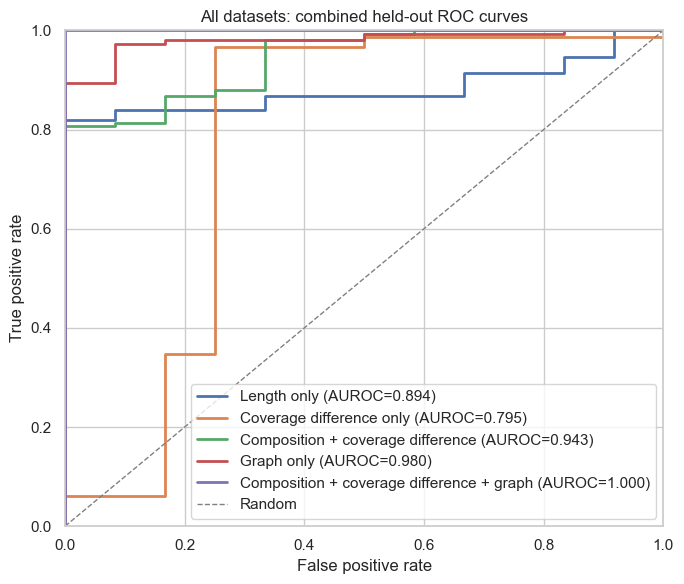

In [7]:
combined_table = combined_dataset_metric_table(
    comparison_results_by_dataset,
    feature_sets=COMPARISON_FEATURE_SETS,
)
display(
    combined_table[
        ["feature_set_label", "n_test", "correct_rate", "auroc", "auprc"]
    ].style.format({"correct_rate": "{:.3f}", "auroc": "{:.3f}", "auprc": "{:.3f}"})
)

fig, ax = plt.subplots(figsize=(7, 6))
plot_combined_dataset_roc_curves(
    comparison_results_by_dataset,
    feature_sets=COMPARISON_FEATURE_SETS,
    ax=ax,
)
ax.set_title("All datasets: combined held-out ROC curves")
plt.tight_layout()
plt.show()

## Dataset Transfer Heatmaps

This section evaluates whether the full `composition_coverage_graph` model transfers between the discovered datasets in `tests/data/`. Rows are training datasets and columns are test datasets. Diagonal cells use a 70/30 held-out split within the same dataset; off-diagonal cells train on all labelled rows from the source dataset and test on all labelled rows from the target dataset. The second heatmap reports failure-class AUPRC, using `1 - correctness_score` as the predicted failure risk.

,train_dataset,test_dataset,evaluation_mode,n_features,n_train,n_test,failure_rate_test,auroc,failure_auprc
0,Sim-10G,Sim-10G,within_dataset_holdout,30,231,100,0.080,1.000,1.000
1,Sim-10G,Sim-5G,cross_dataset_transfer,30,331,206,0.068,0.991,0.941
2,Sim-5G,Sim-10G,cross_dataset_transfer,30,206,331,0.076,0.960,0.824
3,Sim-5G,Sim-5G,within_dataset_holdout,30,144,62,0.065,1.000,1.000


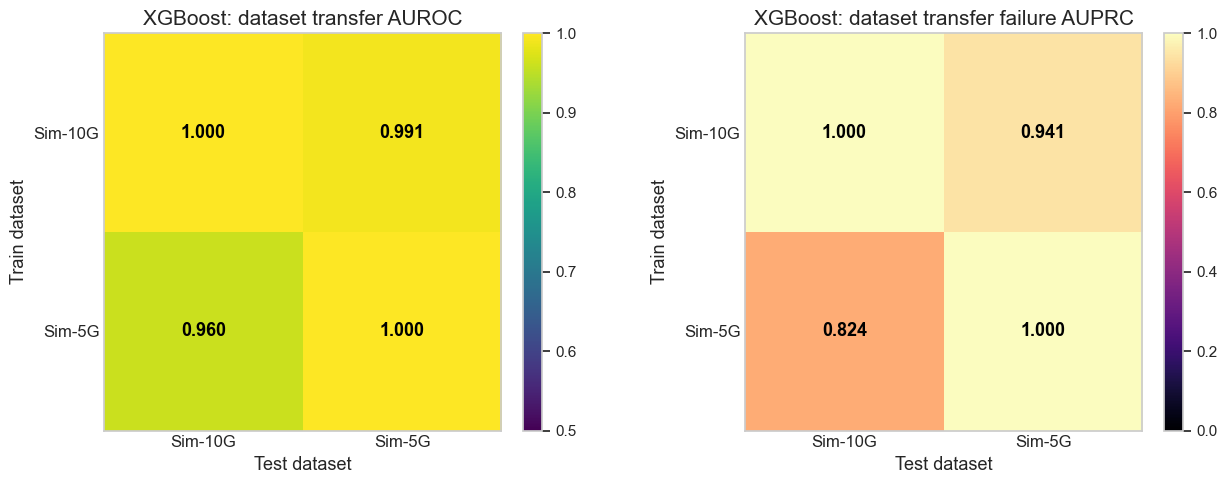

In [8]:
TRANSFER_FEATURE_SET = "composition_coverage_graph"

transfer_metrics_table = transfer_feature_set_table(
    dataset_tasks,
    model_factory=lambda train_task: MODEL_FACTORY(train_task),
    feature_set=TRANSFER_FEATURE_SET,
    target_col="target",
    test_size=0.30,
    random_state=42,
)

display(
    transfer_metrics_table[
        [
            "train_dataset",
            "test_dataset",
            "evaluation_mode",
            "n_features",
            "n_train",
            "n_test",
            "failure_rate_test",
            "auroc",
            "failure_auprc",
        ]
    ].style.format(
        {
            "failure_rate_test": "{:.3f}",
            "auroc": "{:.3f}",
            "failure_auprc": "{:.3f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_transfer_heatmap(
    transfer_metrics_table,
    metric="auroc",
    ax=axes[0],
    title=f"{MODEL_NAME}: dataset transfer AUROC",
    vmin=0.5,
    vmax=1.0,
    cmap="viridis",
)
plot_transfer_heatmap(
    transfer_metrics_table,
    metric="failure_auprc",
    ax=axes[1],
    title=f"{MODEL_NAME}: dataset transfer failure AUPRC",
    vmin=0.0,
    vmax=1.0,
    cmap="magma",
)
plt.tight_layout()
plt.show()

## External Test Dataset

This section trains the current model on all datasets in `tests/data/` using the `composition_coverage_graph` feature set, then tests it on every dataset discovered under `tests/test_data/`, such as `Sim-20G`. It reports AUROC, AUPRC, threshold-based classification metrics, calibration error, top-10% precision/recall, a confusion matrix, and an external-test ROC curve.

External test: trained XGBoost on 537 rows from tests/data and tested on 1 dataset(s) from tests/test_data.
Feature set: composition_coverage_graph (30 features)


,dataset,graph_contigs,initial_binned_contigs,test_rows,incorrect_assignments,correct_assignments
0,Sim-20G,1452,610,597,58,539


,dataset,model,n_train,n_test,correct_rate_test,auroc,auprc,accuracy,f1,precision,recall,ece_10bin,precision_at_top_10pct,recall_at_top_10pct
0,Sim-20G,XGBoost,537,597,0.903,0.992,0.999,0.970,0.983,0.983,0.983,0.026,1.000,0.111


,Predicted incorrect (0),Predicted correct (1)
True incorrect (0),49,9
True correct (1),9,530


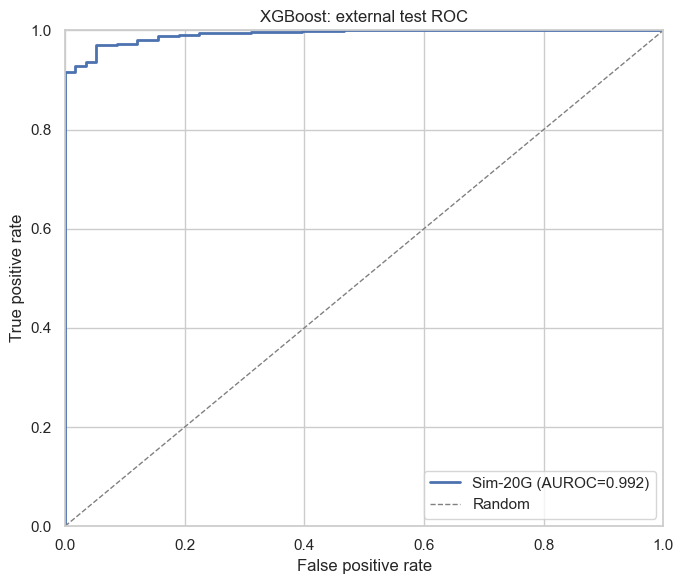

In [9]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from binfailgraph.modeling import expected_calibration_error, precision_recall_at_top_k

EXTERNAL_DATA_ROOT = ROOT / "tests" / "test_data"
WINNING_FEATURE_SET = "composition_coverage_graph"

if not EXTERNAL_DATA_ROOT.exists():
    print(f"No external test-data directory found at {EXTERNAL_DATA_ROOT}")
else:
    external_datasets = discover_datasets(EXTERNAL_DATA_ROOT)
    external_features = {}
    external_tasks = {}
    external_summary_rows = []

    for dataset in external_datasets:
        raw_features = build_feature_table(
            graph_file=dataset.graph_file,
            contigs_file=dataset.contigs_file,
            contig_paths_file=dataset.contig_paths_file,
            ground_truth_file=dataset.ground_truth_file,
            bin_assignments_file=dataset.bin_assignments_file,
            include_kmers=INCLUDE_KMERS,
        )
        labelled = make_contig_labels(raw_features)
        task = task_frame(labelled, task=TASK)

        external_features[dataset.name] = raw_features
        external_tasks[dataset.name] = task
        external_summary_rows.append(
            {
                "dataset": dataset.name,
                "graph_contigs": len(raw_features),
                "initial_binned_contigs": int(raw_features["bin"].notna().sum()),
                "test_rows": len(task),
                "incorrect_assignments": int((task["target"] == 0).sum()),
                "correct_assignments": int(task["target"].sum()),
            }
        )

    train_task = pd.concat(
        [task.assign(dataset=dataset_name) for dataset_name, task in dataset_tasks.items()],
        ignore_index=True,
    )
    external_feature_columns = select_feature_columns(
        train_task,
        feature_set=WINNING_FEATURE_SET,
        target_col="target",
    )
    x_train = train_task[external_feature_columns]
    y_train = train_task["target"].astype(int)

    external_model = MODEL_FACTORY(train_task)
    external_model.fit(x_train, y_train)

    external_metric_rows = []
    external_confusion_matrices = {}
    external_roc_curves = []

    for dataset_name, test_task in external_tasks.items():
        missing_columns = [
            column for column in external_feature_columns if column not in test_task.columns
        ]
        if missing_columns:
            raise ValueError(
                f"{dataset_name} is missing external-test feature columns: {missing_columns}"
            )

        x_test = test_task[external_feature_columns]
        y_test = test_task["target"].astype(int)
        y_score = external_model.predict_proba(x_test)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)
        precision_top, recall_top = precision_recall_at_top_k(y_test, y_score, 0.10)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        external_metric_rows.append(
            {
                "dataset": dataset_name,
                "model": MODEL_NAME,
                "feature_set": WINNING_FEATURE_SET,
                "n_train": len(y_train),
                "n_test": len(y_test),
                "correct_rate_test": float(y_test.mean()),
                "auroc": roc_auc_score(y_test, y_score),
                "auprc": average_precision_score(y_test, y_score),
                "accuracy": accuracy_score(y_test, y_pred),
                "f1": f1_score(y_test, y_pred, zero_division=0),
                "precision": precision_score(y_test, y_pred, zero_division=0),
                "recall": recall_score(y_test, y_pred, zero_division=0),
                "ece_10bin": expected_calibration_error(y_test, y_score, n_bins=10),
                "precision_at_top_10pct": precision_top,
                "recall_at_top_10pct": recall_top,
            }
        )
        external_confusion_matrices[dataset_name] = pd.DataFrame(
            [[int(tn), int(fp)], [int(fn), int(tp)]],
            index=["True incorrect (0)", "True correct (1)"],
            columns=["Predicted incorrect (0)", "Predicted correct (1)"],
        )

        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        external_roc_curves.append(
            {
                "dataset": dataset_name,
                "fpr": fpr,
                "tpr": tpr,
                "thresholds": thresholds,
                "auroc": roc_auc_score(y_test, y_score),
            }
        )

    external_summary_table = pd.DataFrame(external_summary_rows)
    external_metrics_table = pd.DataFrame(external_metric_rows)

    print(
        f"External test: trained {MODEL_NAME} on {len(y_train):,} rows from tests/data "
        f"and tested on {len(external_tasks):,} dataset(s) from tests/test_data."
    )
    print(f"Feature set: {WINNING_FEATURE_SET} ({len(external_feature_columns)} features)")
    display(external_summary_table)
    display(
        external_metrics_table[
            [
                "dataset",
                "model",
                "n_train",
                "n_test",
                "correct_rate_test",
                "auroc",
                "auprc",
                "accuracy",
                "f1",
                "precision",
                "recall",
                "ece_10bin",
                "precision_at_top_10pct",
                "recall_at_top_10pct",
            ]
        ].style.format(
            {
                "correct_rate_test": "{:.3f}",
                "auroc": "{:.3f}",
                "auprc": "{:.3f}",
                "accuracy": "{:.3f}",
                "f1": "{:.3f}",
                "precision": "{:.3f}",
                "recall": "{:.3f}",
                "ece_10bin": "{:.3f}",
                "precision_at_top_10pct": "{:.3f}",
                "recall_at_top_10pct": "{:.3f}",
            }
        )
    )
    for dataset_name, confusion_matrix_table in external_confusion_matrices.items():
        display(
            confusion_matrix_table.style.set_caption(
                f"{dataset_name}: {MODEL_NAME} confusion matrix"
            )
        )

    fig, ax = plt.subplots(figsize=(7, 6))
    for curve in external_roc_curves:
        ax.step(
            curve["fpr"],
            curve["tpr"],
            where="post",
            linewidth=2,
            label=f"{curve['dataset']} (AUROC={curve['auroc']:.3f})",
        )
    ax.plot([0, 1], [0, 1], linestyle="--", color="0.5", linewidth=1, label="Random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{MODEL_NAME}: external test ROC")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## Full Feature-Set Importance

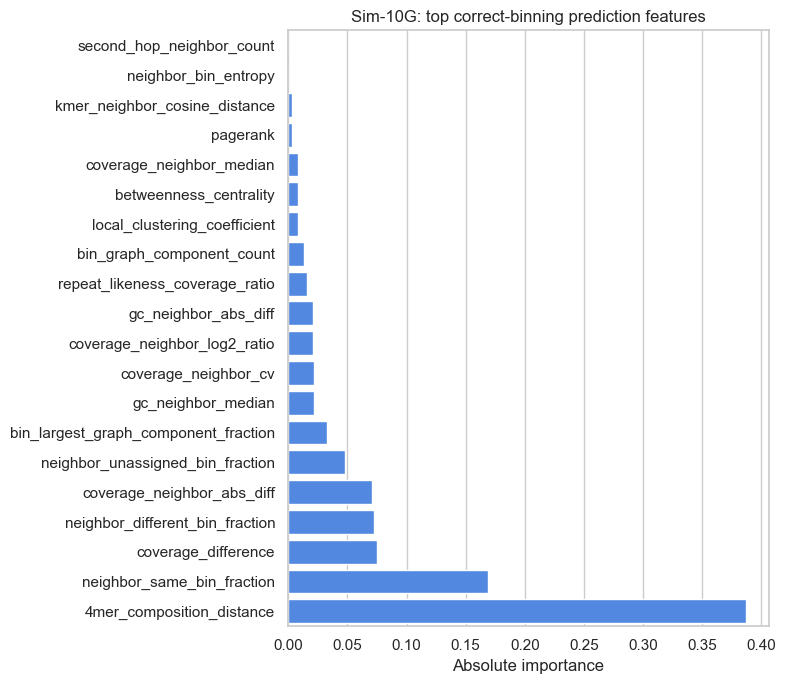

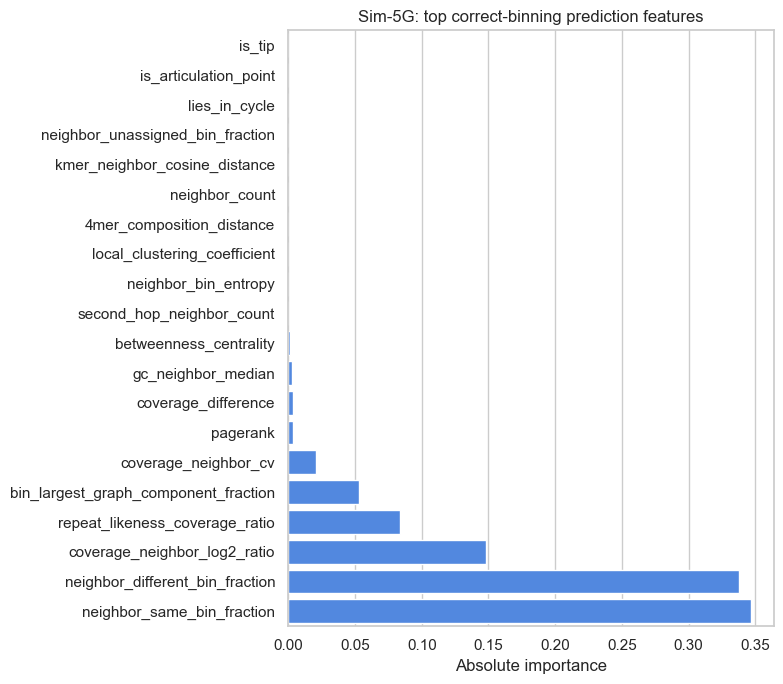

In [10]:
for dataset_name, results in comparison_results_by_dataset.items():
    top = results["composition_coverage_graph"].feature_importance.head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 7))
    if sns is not None:
        sns.barplot(data=top, x="abs_importance", y="feature", ax=ax, color="#3b82f6")
    else:
        ax.barh(top["feature"], top["abs_importance"], color="#3b82f6")
    ax.set_xlabel("Absolute importance")
    ax.set_ylabel("")
    ax.set_title(f"{dataset_name}: top correct-binning prediction features")
    plt.tight_layout()
    plt.show()

## SHAP Summary

Optional SHAP summary for the primary dataset using the composition + coverage difference + graph feature set. This can be slower than built-in feature importance.

/Users/vijinimallawaarachchi/miniforge3/envs/binfailgraph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


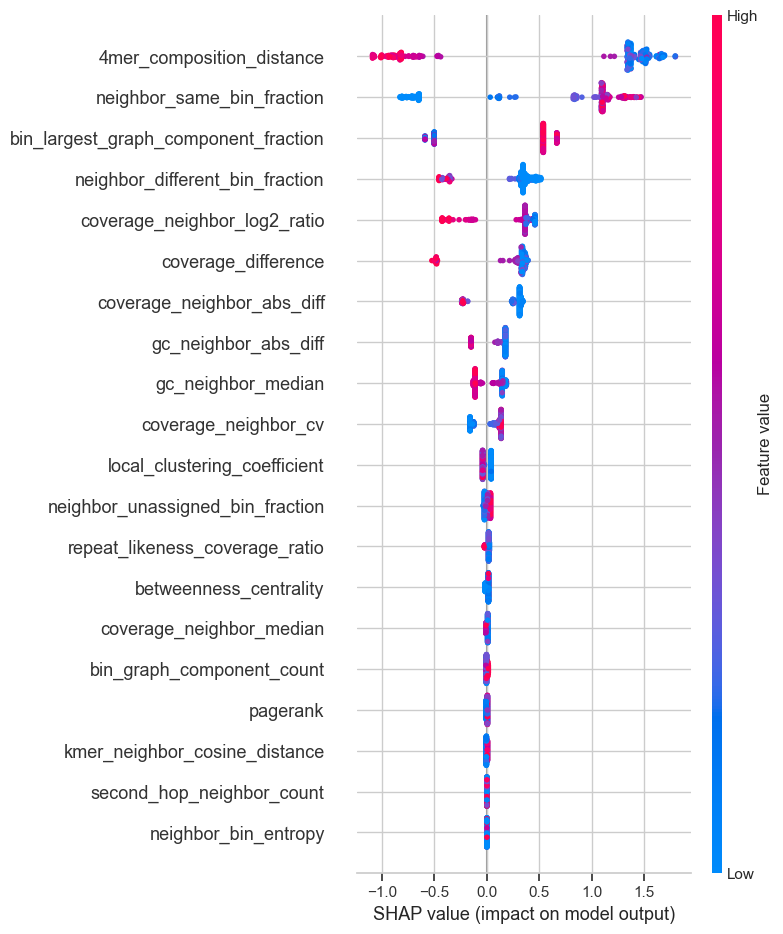

In [11]:
try:
    import shap

    transformed = result.model.named_steps["impute"].transform(primary_task[feature_columns])
    explainer = shap.TreeExplainer(result.model.named_steps["model"])
    shap_values = explainer.shap_values(transformed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif getattr(shap_values, "ndim", 0) == 3:
        shap_values = shap_values[:, :, 1]
    shap.summary_plot(shap_values, transformed, feature_names=feature_columns, max_display=20)
except ImportError:
    print("Install shap from environment.yml to run this cell.")